# Feature Representation Variations

This notebook investigates **Step 3: Feature Representation Variations** for empathy classification.

At this stage, we **fix the best model and the best preprocessing pipeline** found in the previous sections, and vary only the **feature representation**. This keeps the experiment controlled and lets us measure the effect of the representation itself.

## 1. Research question and hypothesis

### Research question
How does the choice of feature representation affect empathy classification performance when the **model** and **preprocessing** are fixed?

### Hypothesis
Different feature representations capture different types of signal:

- **TF-IDF unigram** is the reference representation.
- **TF-IDF unigram + bigram** may improve performance by capturing short empathetic phrases such as *"feel for"*, *"so sorry"*, or *"you are"*.
- **TF-IDF unigram + bigram + trigram** may capture more context, but may also become sparse and noisy.
- **Bag-of-Words** provides a simpler count-based baseline to compare against TF-IDF weighting.
- **Character n-grams** may help with informal writing, spelling variation, elongated words, and internet-style language.
- **LDA topic distribution** captures the thematic context of each post. Our EDA revealed that certain topics (e.g. Emotional Support, Emotional Reflection) are more associated with empathy, so topic membership may add useful signal.
- **Combined features** (TF-IDF + LDA) may outperform any single representation by providing complementary information.

### Experimental principle
Only the **feature representation** changes.
Everything else stays fixed:
- **Model**: Logistic Regression
- **Preprocessing**: best preprocessing from Step 2 = **keep stopwords**
- **Train/test split**: same random seed and same test size for fair comparison

## 2. Experimental plan

We will run seven experiments:

- **F1** — Best preprocessing + TF-IDF unigram
- **F2** — Best preprocessing + TF-IDF unigram + bigram
- **F3** — Best preprocessing + TF-IDF unigram + bigram + trigram
- **F4** — Best preprocessing + Bag-of-Words
- **F5** — Best preprocessing + Character n-grams
- **F6** — Best preprocessing + LDA topic distribution
- **F7** — Best preprocessing + TF-IDF trigram + LDA (combined)

### What we want to learn
This section answers a focused question:

> After choosing the best classical model and best preprocessing, what text representation gives the strongest signal for empathy detection?

We will compare the feature sets using:
- Accuracy
- Macro-F1
- Precision / Recall / F1 for the empathy class
- Precision / Recall / F1 for the no-empathy class
- Confusion matrices

In [1]:
import re
import unicodedata
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp

from pathlib import Path

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    f1_score,
    confusion_matrix,
)

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

## 3. Download and load resources

We use NLTK resources for token normalization and stopword handling.
Even though the selected preprocessing keeps stopwords, we keep the setup complete and reproducible.

In [2]:
for resource, name in [
    ("tokenizers/punkt", "punkt"),
    ("corpora/stopwords", "stopwords"),
    ("corpora/wordnet", "wordnet"),
    ("corpora/omw-1.4", "omw-1.4"),
]:
    try:
        nltk.data.find(resource)
    except LookupError:
        nltk.download(name)

[nltk_data] Downloading package wordnet to /Users/gjoli/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /Users/gjoli/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## 4. Load the dataset

This step loads the same dataset used in the previous notebooks.
We keep the path logic flexible so the notebook works whether the dataset is in the current folder or in a common project location.

In [3]:
df = pd.read_csv("AcnEmpathize_dataset.csv")
df = df[['text', 'combined_empathy']].copy()
df = df.rename(columns={'combined_empathy': 'label'})
df.head()

,text,label
0,"Hello! I've been having a hard time, lingeri...",0
1,"Hey man the pictures are not present, can you ...",0
2,There are many many many many many many many d...,0
3,Maybe in some African tribe my face scars woul...,0
4,None of those opinions consider acne to be bea...,0


## 5. Basic cleaning of missing values and labels

Before applying preprocessing, we make sure labels are numeric and binary.

This step is not one of the experimental variations.
It is a **basic preparation step** required so that all experiments use valid input data.

In [4]:
df = df[["text", "label"]].copy()
df = df.dropna(subset=["text", "label"])

label_map = {"no_empathy": 0, "empathy": 1}
df["label"] = df["label"].map(lambda x: label_map.get(x, x))
df = df[df["label"].isin([0, 1])].copy()
df["text"] = df["text"].astype(str)

print("Shape after filtering:", df.shape)
print(df["label"].value_counts(dropna=False))

Shape after filtering: (12212, 2)
label
0    9236
1    2976
Name: count, dtype: int64


## 6. Define the selected preprocessing pipeline

From Step 2, the best preprocessing was **keep stopwords**.
So here we implement exactly that preprocessing and keep it fixed for all feature experiments.

### What this preprocessing does
- lowercase
- remove punctuation
- lemmatize
- **keep stopwords**

This design keeps relational words such as *you*, *I*, and *we*, which may be useful for empathy detection.

In [5]:
lemmatizer = WordNetLemmatizer()

def normalize_text_keep_stopwords(text: str) -> str:
    text = text.replace("\n", " ").replace("\r", " ").strip().lower()
    text = unicodedata.normalize("NFKD", text)
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = text.split()
    if not any(re.search(r"[a-z]", tok) for tok in tokens):
        return ""
    lemmas = [lemmatizer.lemmatize(tok) for tok in tokens]
    return " ".join(lemmas)

df["text_preprocessed"] = df["text"].apply(normalize_text_keep_stopwords)
df = df[df["text_preprocessed"].str.strip() != ""].copy()

df[["text_preprocessed", "label"]].head()

,text_preprocessed,label
0,hello i ve been having a hard time lingering a...,0
1,hey man the picture are not present can you po...,0
2,there are many many many many many many many d...,0
3,maybe in some african tribe my face scar would...,0
4,none of those opinion consider acne to be beau...,0


## 7. Train/test split

We create one fixed split and reuse it for all experiments.
This is important for fairness: every feature representation is evaluated on the **same train and test instances**.

In [6]:
X = df["text_preprocessed"]
y = df["label"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print("Train size:", len(X_train))
print("Test size :", len(X_test))
print("\nTrain label distribution:")
print(y_train.value_counts(normalize=True))
print("\nTest label distribution:")
print(y_test.value_counts(normalize=True))

Train size: 9769
Test size : 2443

Train label distribution:
label
0    0.75627
1    0.24373
Name: proportion, dtype: float64

Test label distribution:
label
0    0.756447
1    0.243553
Name: proportion, dtype: float64


## 8. LDA topic distribution features

We apply **Latent Dirichlet Allocation** to discover the main themes in the forum.
The key intuition is that empathy is not uniformly distributed across topics: posts in emotionally reflective conversations are more likely to be empathetic than posts about skincare routines or medical treatments.

We fit the LDA model **on the training split only** to prevent leakage, then transform both splits to obtain 10-dimensional topic distribution vectors.

In [7]:
# Fit BoW vectorizer on training data only — no leakage
lda_count_vectorizer = CountVectorizer(max_features=5000)
X_train_lda_counts = lda_count_vectorizer.fit_transform(X_train)
X_test_lda_counts  = lda_count_vectorizer.transform(X_test)

# Fit LDA on training data only
N_TOPICS = 10
lda_model = LatentDirichletAllocation(n_components=N_TOPICS, random_state=42, max_iter=20)
lda_model.fit(X_train_lda_counts)

# Transform both splits to topic distributions
X_train_lda = lda_model.transform(X_train_lda_counts)  # (n_train, 10)
X_test_lda  = lda_model.transform(X_test_lda_counts)   # (n_test,  10)

print("LDA train features shape:", X_train_lda.shape)
print("LDA test  features shape:", X_test_lda.shape)

LDA train features shape: (9769, 10)
LDA test  features shape: (2443, 10)


### Inspect the topics

In [18]:
TOPIC_LABELS = {
    0: "Emotional Support",
    1: "Appearance & Social Perception",
    2: "Social Struggles Over Time",
    3: "Medical Treatment",
    4: "Skincare Routines",
    5: "Diet & Causes",
    6: "Acne Symptoms",
    7: "Emotional Reflection",
    8: "General Emotional Language",
    9: "School / Social Environment",
}

vocab = lda_count_vectorizer.get_feature_names_out()


### Topic distribution by label

Before using LDA features as inputs, we check whether topic weights actually differ between empathetic and non-empathetic posts.

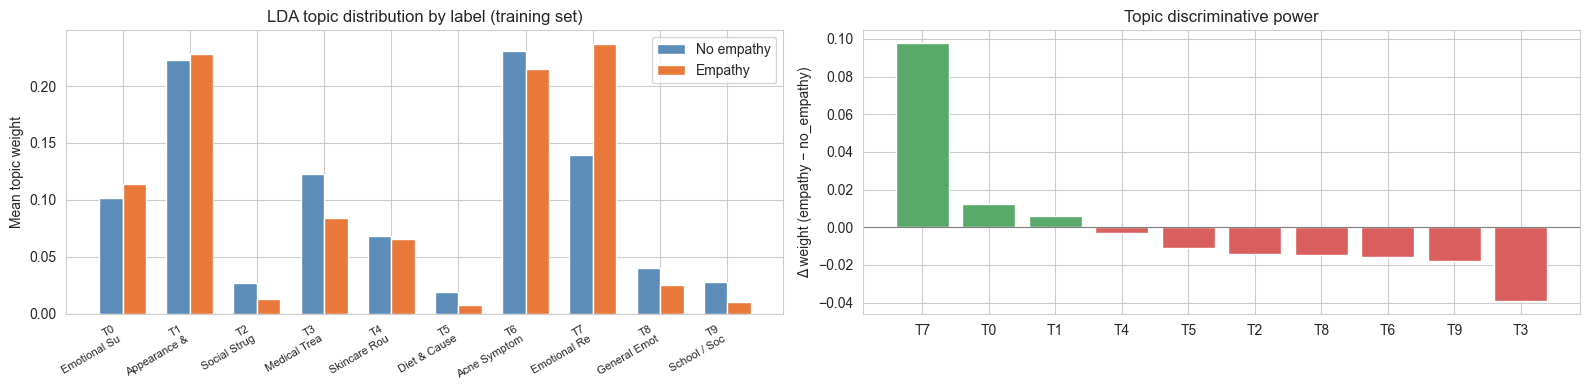


Topics most associated with empathy:
  topic_7 (Emotional Reflection               ): delta = +0.0976
  topic_0 (Emotional Support                  ): delta = +0.0121
  topic_1 (Appearance & Social Perception     ): delta = +0.0058
  topic_4 (Skincare Routines                  ): delta = -0.0029
  topic_5 (Diet & Causes                      ): delta = -0.0109
  topic_2 (Social Struggles Over Time         ): delta = -0.0144
  topic_8 (General Emotional Language         ): delta = -0.0145
  topic_6 (Acne Symptoms                      ): delta = -0.0159
  topic_9 (School / Social Environment        ): delta = -0.0177
  topic_3 (Medical Treatment                  ): delta = -0.0392


In [9]:
lda_df = pd.DataFrame(X_train_lda, columns=[f"topic_{i}" for i in range(N_TOPICS)])
lda_df["label"] = y_train.values
mean_topics = lda_df.groupby("label")[[f"topic_{i}" for i in range(N_TOPICS)]].mean()

width = 0.35
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

x = np.arange(N_TOPICS)
axes[0].bar(x - width/2, mean_topics.loc[0], width, label="No empathy", color="#5B8DB8")
axes[0].bar(x + width/2, mean_topics.loc[1], width, label="Empathy", color="#E8793A")
topic_names = [f"T{i}\n{TOPIC_LABELS.get(i,'')[:12]}" for i in range(N_TOPICS)]
axes[0].set_xticks(x)
axes[0].set_xticklabels(topic_names, rotation=30, ha="right", fontsize=8)
axes[0].set_ylabel("Mean topic weight")
axes[0].set_title("LDA topic distribution by label (training set)")
axes[0].legend()

delta_lda = (mean_topics.loc[1] - mean_topics.loc[0]).sort_values(ascending=False)
bar_colors = ["#59A96A" if v > 0 else "#D95F5F" for v in delta_lda.values]
axes[1].bar([f"T{c.split('_')[1]}" for c in delta_lda.index], delta_lda.values, color=bar_colors)
axes[1].axhline(0, color="gray", linewidth=0.8)
axes[1].set_ylabel("Δ weight (empathy − no_empathy)")
axes[1].set_title("Topic discriminative power")

plt.tight_layout()
plt.show()

print("\nTopics most associated with empathy:")
for col, val in delta_lda.items():
    idx = int(col.split("_")[1])
    print(f"  topic_{idx} ({TOPIC_LABELS.get(idx,'?'):35s}): delta = {val:+.4f}")

## 9. Define the feature representation experiments

Now we define all feature representations to compare.

### Why these settings?
- **F1** is the reference representation.
- **F2** tests whether short phrases help.
- **F3** tests whether more context helps or hurts.
- **F4** checks whether raw counts are enough.
- **F5** checks whether subword patterns help with informal language.
- **F6** tests whether topic membership adds signal on its own.
- **F7** tests whether combining TF-IDF with topic features yields gains over either alone.

In [10]:
feature_configs = {
    "F1_tfidf_unigram": TfidfVectorizer(ngram_range=(1, 1), max_features=5000),
    "F2_tfidf_unigram_bigram": TfidfVectorizer(ngram_range=(1, 2), max_features=5000),
    "F3_tfidf_unigram_bigram_trigram": TfidfVectorizer(ngram_range=(1, 3), max_features=5000),
    "F4_bag_of_words": CountVectorizer(ngram_range=(1, 1), max_features=5000),
    "F5_character_ngrams": TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), max_features=5000),
}

## 10. Define the fixed model

We keep the best model from the baseline section: **Logistic Regression**.

The goal here is not to tune the model again.
The goal is to isolate the effect of the **feature representation**.

In [11]:
def build_model():
    return LogisticRegression(max_iter=1000, random_state=42)

## 11. Define the evaluation function

This helper function trains one experiment, predicts on the test set, and returns:

- the trained vectorizer
- the trained model
- predictions
- evaluation metrics

This keeps the notebook clean and makes the experiment loop easier to read.

In [12]:
def run_experiment(experiment_name, vectorizer, X_train, X_test, y_train, y_test):
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)

    model = build_model()
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, labels=[1, 0], zero_division=0
    )
    macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
    accuracy = accuracy_score(y_test, y_pred)

    result = {
        "experiment": experiment_name,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "precision_empathy": precision[0],
        "recall_empathy": recall[0],
        "f1_empathy": f1[0],
        "precision_no_empathy": precision[1],
        "recall_no_empathy": recall[1],
        "f1_no_empathy": f1[1],
        "n_features_used": X_train_vec.shape[1],
    }

    return {
        "vectorizer": vectorizer,
        "model": model,
        "y_pred": y_pred,
        "metrics": result
    }

def evaluate_precomputed(experiment_name, y_true, y_pred, n_features):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=[1, 0], zero_division=0
    )
    return {
        "experiment": experiment_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "precision_empathy": precision[0],
        "recall_empathy": recall[0],
        "f1_empathy": f1[0],
        "precision_no_empathy": precision[1],
        "recall_no_empathy": recall[1],
        "f1_no_empathy": f1[1],
        "n_features_used": n_features,
    }

## 12. Run all feature representation experiments

This is the core experiment loop.

For each feature representation:
1. vectorize the preprocessed text
2. train Logistic Regression
3. evaluate on the same test split
4. store results for comparison

In [13]:
results = []
predictions = {}
trained_objects = {}

# ── F1–F5: sparse representations ────────────────────────────────────────────
for exp_name, vectorizer in feature_configs.items():
    output = run_experiment(exp_name, vectorizer, X_train, X_test, y_train, y_test)
    results.append(output["metrics"])
    predictions[exp_name] = output["y_pred"]
    trained_objects[exp_name] = {"vectorizer": output["vectorizer"], "model": output["model"]}

# ── F6: LDA topic distribution only ──────────────────────────────────────────
model_f6 = build_model()
model_f6.fit(X_train_lda, y_train)
y_pred_f6 = model_f6.predict(X_test_lda)
predictions["F6_lda_only"] = y_pred_f6
results.append(evaluate_precomputed("F6_lda_only", y_test, y_pred_f6, X_train_lda.shape[1]))

# ── F7: TF-IDF trigram + LDA (combined) ──────────────────────────────────────
# Re-fit the best sparse vectorizer to get clean matrices for combination
tfidf_best = TfidfVectorizer(ngram_range=(1, 3), max_features=5000)
Xtr_tfidf = tfidf_best.fit_transform(X_train)
Xte_tfidf = tfidf_best.transform(X_test)

Xtr_f7 = sp.hstack([Xtr_tfidf, sp.csr_matrix(X_train_lda)])
Xte_f7 = sp.hstack([Xte_tfidf, sp.csr_matrix(X_test_lda)])
model_f7 = build_model()
model_f7.fit(Xtr_f7, y_train)
y_pred_f7 = model_f7.predict(Xte_f7)
predictions["F7_tfidf_lda"] = y_pred_f7
results.append(evaluate_precomputed("F7_tfidf_lda", y_test, y_pred_f7, Xtr_f7.shape[1]))

results_df = pd.DataFrame(results).sort_values(
    by=["macro_f1", "f1_empathy", "accuracy"],
    ascending=False,
).reset_index(drop=True)

results_df

,experiment,accuracy,macro_f1,precision_empathy,recall_empathy,f1_empathy,precision_no_empathy,recall_no_empathy,f1_no_empathy,n_features_used
0,F7_tfidf_lda,0.849775,0.758870,0.827586,0.484034,0.610817,0.853461,0.967532,0.906924,5010
1,F3_tfidf_unigram_bigram_trigram,0.848138,0.754654,0.829412,0.473950,0.603209,0.851165,0.968615,0.906100,5000
2,F2_tfidf_unigram_bigram,0.846500,0.752815,0.819767,0.473950,0.600639,0.850881,0.966450,0.904991,5000
3,F1_tfidf_unigram,0.835448,0.737773,0.770308,0.462185,0.577731,0.846596,0.955628,0.897814,5000
4,F4_bag_of_words,0.810070,0.734558,0.620183,0.568067,0.592982,0.864594,0.887987,0.876135,5000
5,F5_character_ngrams,0.831355,0.732102,0.753463,0.457143,0.569038,0.844861,0.951840,0.895165,5000
6,F6_lda_only,0.742939,0.444243,0.210526,0.020168,0.036810,0.755658,0.975649,0.851677,10


## 13. Statistical Significance Test

Although the combined TF-IDF + LDA representation (F7) shows slightly better performance than TF-IDF n-grams alone (F3), the observed improvement is very small. To determine whether this difference reflects a real performance gain or is due to random variation, we perform a paired **bootstrap significance test on the F1 score**.

This test resamples the test set multiple times and compares both models on the same samples, allowing us to estimate whether the performance difference is statistically significant.

In [23]:
def bootstrap_f1_test(y_true, y_pred_a, y_pred_b, n_iterations=1000, seed=42):
    rng = np.random.RandomState(seed)

    # 🔥 FIX: convert to numpy
    y_true = np.array(y_true)
    y_pred_a = np.array(y_pred_a)
    y_pred_b = np.array(y_pred_b)

    diffs = []
    n = len(y_true)

    for _ in range(n_iterations):
        idx = rng.choice(n, n, replace=True)

        f1_a = f1_score(y_true[idx], y_pred_a[idx])
        f1_b = f1_score(y_true[idx], y_pred_b[idx])

        diffs.append(f1_b - f1_a)

    diffs = np.array(diffs)
    p_value = np.mean(diffs <= 0)

    return diffs.mean(), p_value

In [24]:
mean_diff, p_value = bootstrap_f1_test(
    y_test,
    predictions["F3_tfidf_unigram_bigram_trigram"],
    predictions["F7_tfidf_lda"]
)

print(f"Mean F1 difference (F7 - F3): {mean_diff:.4f}")
print(f"P-value: {p_value:.4f}")

Mean F1 difference (F7 - F3): 0.0073
P-value: 0.1280


- Although F7 achieves the highest scores, the improvement over F3 is minimal
- The bootstrap test confirms that the difference is not statistically significant (p = 0.128)
- Therefore, adding LDA does not provide a meaningful improvement over TF-IDF n-grams alone

## 13. Highlight the best result

Macro-F1 is the main comparison metric here because the dataset is imbalanced.
Accuracy alone would over-reward predictions of the majority class.

In [14]:
results_df.style.background_gradient(
    subset=["macro_f1", "recall_empathy", "f1_empathy"],
    cmap="Blues"
)

,experiment,accuracy,macro_f1,precision_empathy,recall_empathy,f1_empathy,precision_no_empathy,recall_no_empathy,f1_no_empathy,n_features_used
0,F7_tfidf_lda,0.849775,0.758870,0.827586,0.484034,0.610817,0.853461,0.967532,0.906924,5010
1,F3_tfidf_unigram_bigram_trigram,0.848138,0.754654,0.829412,0.473950,0.603209,0.851165,0.968615,0.906100,5000
2,F2_tfidf_unigram_bigram,0.846500,0.752815,0.819767,0.473950,0.600639,0.850881,0.966450,0.904991,5000
3,F1_tfidf_unigram,0.835448,0.737773,0.770308,0.462185,0.577731,0.846596,0.955628,0.897814,5000
4,F4_bag_of_words,0.810070,0.734558,0.620183,0.568067,0.592982,0.864594,0.887987,0.876135,5000
5,F5_character_ngrams,0.831355,0.732102,0.753463,0.457143,0.569038,0.844861,0.951840,0.895165,5000
6,F6_lda_only,0.742939,0.444243,0.210526,0.020168,0.036810,0.755658,0.975649,0.851677,10


## 14. Visual comparison of the main metrics

This plot makes it easier to compare the representations side by side, especially for:
- Macro-F1
- Empathy precision
- Empathy recall
- Empathy F1

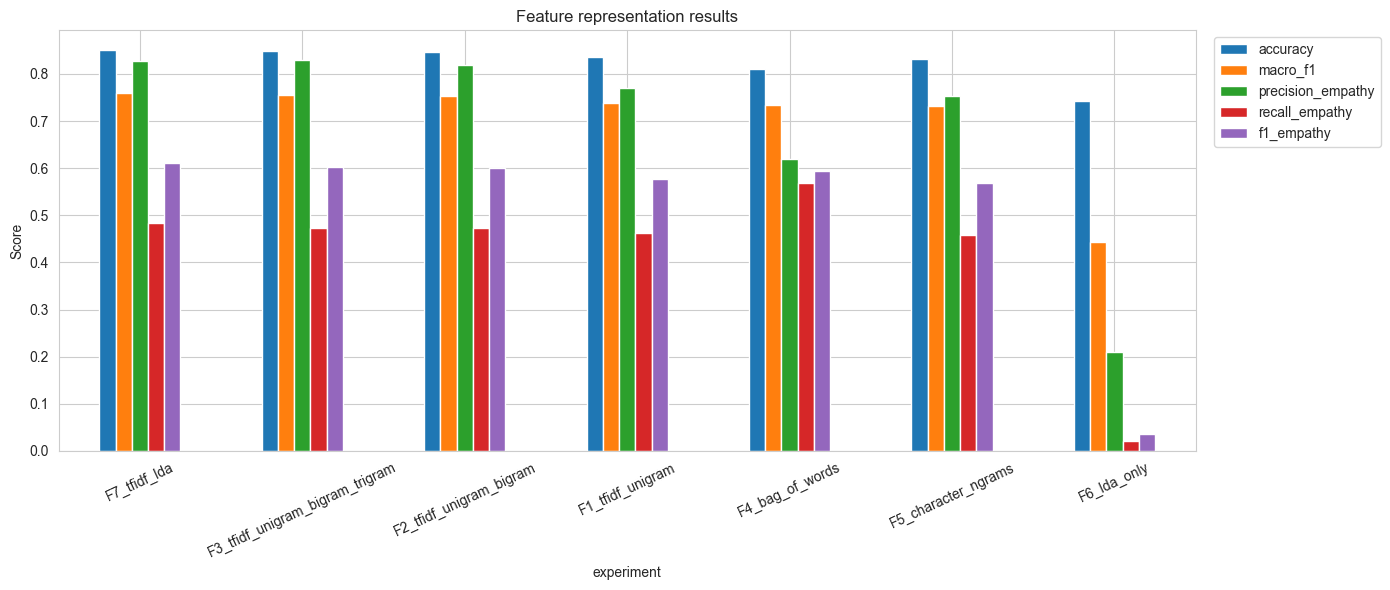

In [15]:
metrics_to_plot = ["accuracy", "macro_f1", "precision_empathy", "recall_empathy", "f1_empathy"]

ax = results_df.set_index("experiment")[metrics_to_plot].plot(
    kind="bar", figsize=(14, 6), rot=25
)
ax.set_title("Feature representation results")
ax.set_ylabel("Score")
ax.set_xlabel("experiment")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

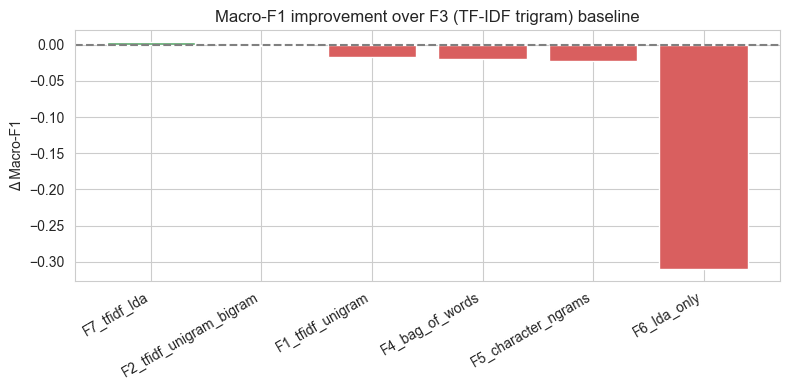

In [16]:
f3_row = results_df[results_df.experiment == "F3_tfidf_unigram_bigram_trigram"].iloc[0]

delta_rows = []
for _, row in results_df.iterrows():
    if row["experiment"] == "F3_tfidf_unigram_bigram_trigram":
        continue
    delta_rows.append({
        "experiment": row["experiment"],
        "delta_macro_f1": row["macro_f1"] - f3_row["macro_f1"],
    })

delta_df = pd.DataFrame(delta_rows).sort_values("delta_macro_f1", ascending=False).reset_index(drop=True)

plt.figure(figsize=(8, 4))
bar_colors = ["#59A96A" if v >= 0 else "#D95F5F" for v in delta_df["delta_macro_f1"]]
plt.bar(delta_df["experiment"], delta_df["delta_macro_f1"], color=bar_colors)
plt.axhline(0, linestyle="--", color="gray")
plt.title("Macro-F1 improvement over F3 (TF-IDF trigram) baseline")
plt.ylabel("Δ Macro-F1")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 15. Confusion matrices

Confusion matrices help us inspect the error profile of each representation:
- How many empathy posts are correctly found?
- How many are missed?
- Is the model biased toward predicting no-empathy?

We plot them side by side for direct comparison.

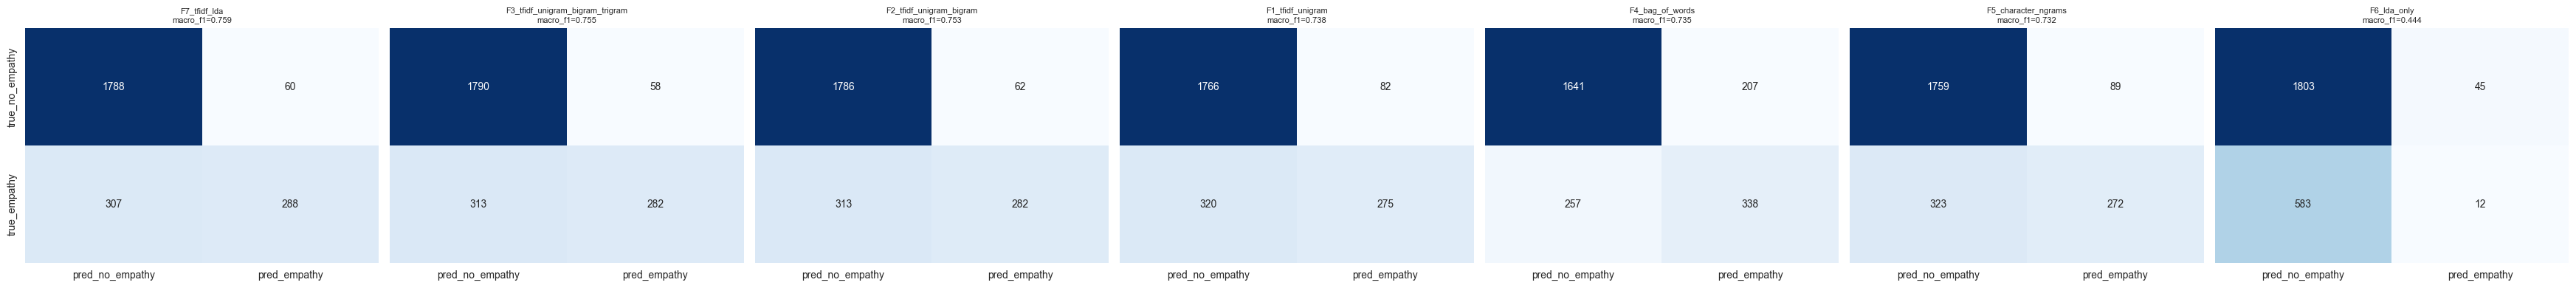

In [17]:
n_models = len(predictions)
ordered_experiments = results_df["experiment"].tolist()

fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4), sharey=True)

if n_models == 1:
    axes = [axes]

for ax, exp_name in zip(axes, ordered_experiments):
    y_pred = predictions[exp_name]
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
        xticklabels=["pred_no_empathy", "pred_empathy"],
        yticklabels=["true_no_empathy", "true_empathy"],
    )
    macro = results_df[results_df.experiment == exp_name]["macro_f1"].values[0]
    ax.set_title(f"{exp_name}\nmacro_f1={macro:.3f}", fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

Conclusions

Feature representation has a clear impact, especially on empathy detection.

- Best overall: F7 (TF-IDF + LDA)
    - Highest accuracy (~0.85), Macro-F1 (~0.76), and empathy F1 (~0.61)
    - Slight improvement over pure TF-IDF, suggesting complementary signal from topics
    - However, in addition to the fact that the improvement is nearly 0, this difference is also not statistical significant, so we will not integrate LDA in further steps

- F3 (TF-IDF unigram + bigram + trigram) performs almost as well

    - Very strong baseline
    - Most gains come from adding bigrams; trigrams provide only marginal improvement

- F1 (unigram) performs worse

    → Lacks contextual information needed for empathy detection

- F4 (Bag-of-Words):
    - Higher empathy recall (~0.57)
    - Lower precision and overall performance

    → Over-predicts empathy
    
- F5 (character n-grams):
    - Slightly worse than word n-grams
        - Helps with noisy text, but lacks semantic clarity

-   F6 (LDA only):
	- Very poor performance
    → Topics alone are insufficient for classification

- **Key insight**
    - Empathy detection benefits from phrase-level features (n-grams)
    - Topic information does not provide statistical significant improvements
    - Best trade-off: TF-IDF up to trigrams

